In [9]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import operator

from  scipy.stats import chi2_contingency
from util.api import calculate_bottom_dict, get_lts_list
%matplotlib inline
plt.style.use('classic')

In [10]:
lts_list = get_lts_list()
df_lengths = []  # Store lengths to avoid keeping full dfs in memory
stability_df = []

for idx, lts in enumerate(lts_list):
    df = pd.read_pickle(f'../../data/dfs/lts-{lts}/lts-{lts}.df')
    df_lengths.append(len(df))
    
    # Process stability data immediately
    list_pkg = []
    list_stab = []
    for _, row in df.iterrows():
        pkg = row['package']
        stabs = row['stability']
        for stab in stabs:
            list_pkg.append(pkg)
            list_stab.append(stab)
    dict_stab = {'package': list_pkg, 'stability': list_stab}
    df_stab = pd.DataFrame(dict_stab)
    
    aux_df = df_stab[['package', 'stability']]
    aux_df = aux_df.groupby(['stability']).count().reset_index().rename(columns={"package": "count"})
    aux_df.loc[:, 'version'] = lts
    stability_df.append(aux_df.sort_values(by=['count'], ascending=False))
    
    # Delete to free memory
    del df, df_stab

# RQ0. Distribution
​
In this section, we respond the following two questions:
​
- How are packages distributed in stackage?
- How are packages using mtl distributed in Stackage?
​
For this, we make the following graphs
​
1. Line graph that shows the number of packets for each published snapshot over time
2. Bar graph that shows the evolution of the main categories of the packages
3. Bar graph that shows the evolution of the stabilities of the packages
4. Bar graph that shows the evolution of the main categories of the packages that depend of `mtl`
5. Bar graph that shows the evolution of the stabilities of the packages that depend of `mtl`
​
## RQ0. 4 - Bar graph that shows the evolution of the main categories of the packages that depend of `mtl`

In [11]:
stabilities = ['', 'experimental', 'stable', 'provisional', 'alpha', 'beta']
data = {
    '': [],
    'experimental': [],
    'stable': [],
    'provisional': [],
    'alpha': [],
    'beta': []
}
count_pkgs = {
    '': [],
    'experimental': [],
    'stable': [],
    'provisional': [],
    'alpha': [],
    'beta': []
}

for stability in stabilities:
    for idx, lts in enumerate(lts_list):
        total_pkgs = df_lengths[idx]
        
        aux = int(stability_df[idx][stability_df[idx]['stability'] == stability]['count'].iloc[0]) * 100 / total_pkgs
        count = int(stability_df[idx][stability_df[idx]['stability'] == stability]['count'].iloc[0])
        count_pkgs[stability].append(count)
        data[stability].append(aux)

stabilities[0]='n/a'
for i in range(len(data['alpha'])):
    data['alpha'][i] = data['alpha'][i] + data['beta'][i]

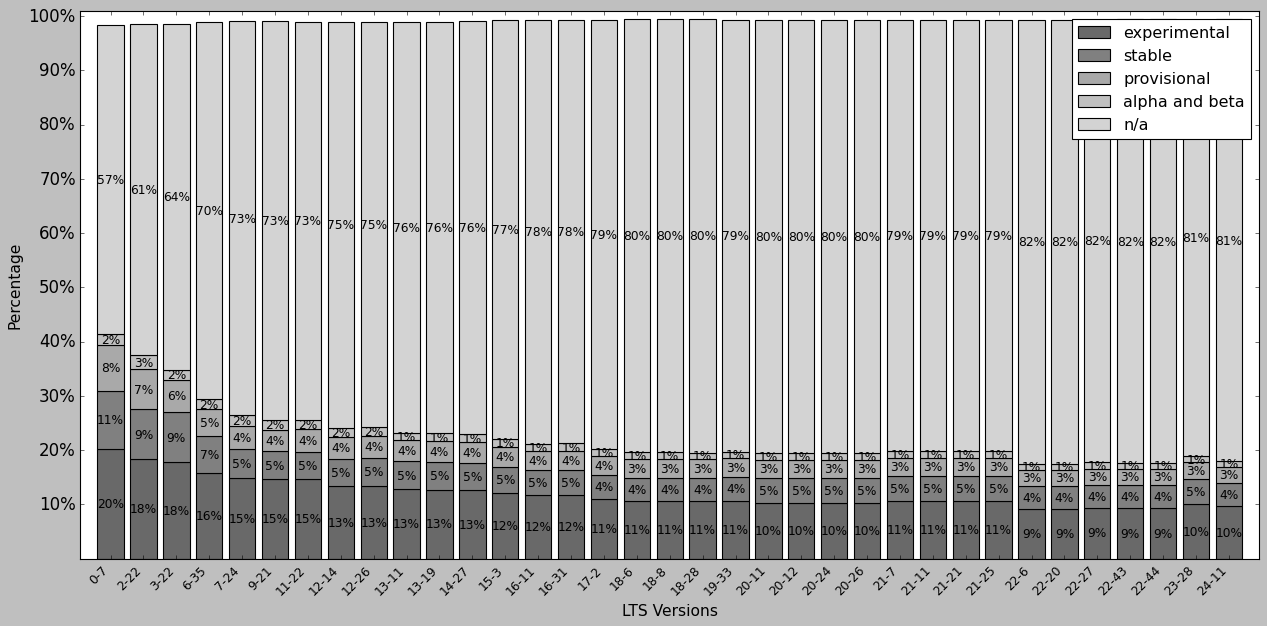

In [13]:
fig, ax = plt.subplots(figsize=(16,8))  # Aumentar ancho para más espacio
ax.margins(0.015) 
plt.subplots_adjust(right=1.1)
stabilities = ['experimental', 'stable', 'provisional', 'alpha and beta','n/a']
stabilities_name = ['experimental', 'stable', 'provisional', 'alpha','']
nom_stabilities = []
colors = ['dimgrey', 'grey', 'darkgrey', 'silver', 'lightgrey','whitesmoke']

# Usar posiciones numéricas para mejor espaciado
x_positions = range(len(lts_list))

for idx, cat in enumerate(stabilities_name):
    nom_stabilities.append(cat)
    bar = ax.bar(x=x_positions, height=data[cat], bottom=calculate_bottom_dict(data, nom_stabilities, idx), width=0.8, color=colors[idx], align='center', label=stabilities[idx])
    # Cambiar a label_type='edge' para colocar etiquetas encima de cada segmento, evitando solapamientos
    ax.bar_label(bar, labels=[f"{round(per)}%" for per in data[cat]], label_type='center', padding=0, fontsize=11, color='black')

ax.legend(loc='upper right', fontsize='large')
ax.set_xticks(x_positions)
ax.set_xticklabels(lts_list, fontsize=11, rotation=45, ha='right')  # Rotar etiquetas para evitar solapamiento
ax.set_yticks([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
ax.set_yticklabels(['10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%'], fontsize=15)
ax.set_xlabel('LTS Versions', fontsize=14)
ax.set_ylabel('Percentage', fontsize=14)
plt.tight_layout()  # Ajustar layout para evitar cortes
plt.savefig("../../graphs/rq0-4.pdf", format='pdf', bbox_inches='tight')
plt.show()